In [1]:
import earthaccess
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter
from datetime import datetime, timedelta
import pandas as pd

# Authenticate with NASA Earthdata
earthaccess.login()


In [2]:
tspan = ("2026-01-25", "2026-01-26")
bbox = (-42, -55, -35, -49.5)
clouds = (0, 70)

results_bgc = earthaccess.search_data(
    short_name="PACE_OCI_L2_BGC",
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds,
)
results_aop = earthaccess.search_data(
    short_name="PACE_OCI_L2_AOP",
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds,
)

# download: https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20260125T163441.L1B.V3.nc
result_l1b = earthaccess.search_data(
    short_name="PACE_OCI_L1B_SCI",
    version="3",
    temporal=tspan,
    bounding_box=bbox,
)


In [3]:
# output_dir_bgc = "/home/zhe2/data/PACE/L2_BGC_V3.1/"
# output_dir_aop = "/home/zhe2/data/PACE/L2_AOP_V3.1/"
# output_dir_l1b = "/home/zhe2/data/PACE/L1B_V3/"

# earthaccess.download(results_bgc[0], local_path=output_dir_bgc)
# earthaccess.download(results_aop[0], local_path=output_dir_aop)
# earthaccess.download(result_l1b[4], local_path=output_dir_l1b)


In [4]:
# download data
# earthaccess.download(results_bgc, local_path="/home/zhe2/data/PACE/L2_BGC_V3.1/")
# earthaccess.download(results_aop, local_path="/home/zhe2/data/PACE/L2_AOP_V3.1/")
# earthaccess.download(result_l1b, local_path="/home/zhe2/data/PACE/L1B_V3/")


QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/12 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/12 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/12 [00:00<?, ?it/s]

['/home/zhe2/data/PACE/L1B_V3/PACE_OCI.20260125T145621.L1B.V3.nc',
 '/home/zhe2/data/PACE/L1B_V3/PACE_OCI.20260125T145621.L1B.V3.nc',
 '/home/zhe2/data/PACE/L1B_V3/PACE_OCI.20260125T162941.L1B.V3.nc',
 '/home/zhe2/data/PACE/L1B_V3/PACE_OCI.20260125T162941.L1B.V3.nc',
 '/home/zhe2/data/PACE/L1B_V3/PACE_OCI.20260125T163441.L1B.V3.nc',
 '/home/zhe2/data/PACE/L1B_V3/PACE_OCI.20260125T163441.L1B.V3.nc',
 '/home/zhe2/data/PACE/L1B_V3/PACE_OCI.20260126T153119.L1B.V3.nc',
 '/home/zhe2/data/PACE/L1B_V3/PACE_OCI.20260126T153119.L1B.V3.nc',
 '/home/zhe2/data/PACE/L1B_V3/PACE_OCI.20260126T170438.L1B.V3.nc',
 '/home/zhe2/data/PACE/L1B_V3/PACE_OCI.20260126T170438.L1B.V3.nc',
 '/home/zhe2/data/PACE/L1B_V3/PACE_OCI.20260126T170938.L1B.V3.nc',
 '/home/zhe2/data/PACE/L1B_V3/PACE_OCI.20260126T170938.L1B.V3.nc']

In [5]:
# read the first granule of results_bgc
granule_bgc = earthaccess.open(results_bgc)
# open data tree
dt_bgc = xr.open_datatree(granule_bgc[0])
# merge
ds_bgc = xr.merge(dt_bgc.to_dict().values())
chlor_a = ds_bgc['chlor_a'].values


QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

In [69]:
# vis
lat = ds_bgc['latitude'].values
lon = ds_bgc['longitude'].values


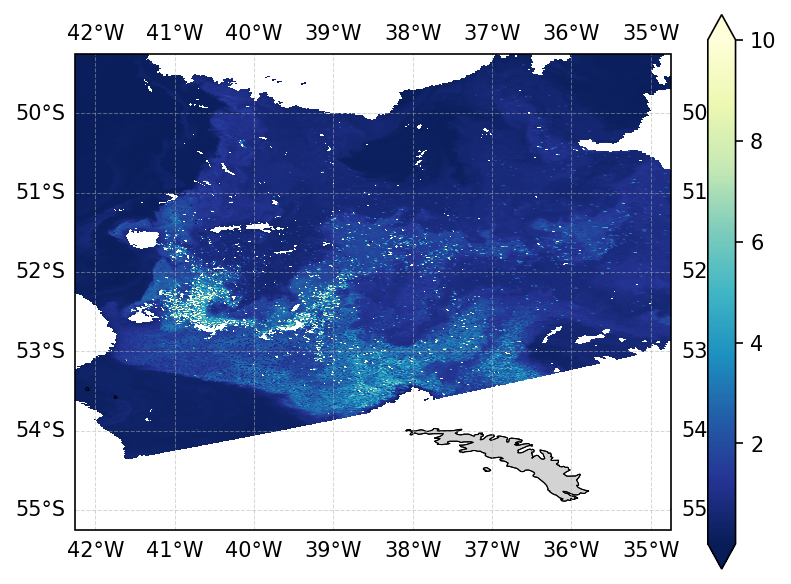

In [ ]:
# mapping
fig = plt.figure(dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

# extent
buffer_bnd = .25
BBOX = bbox
lon_min = BBOX[0] - buffer_bnd
lon_max = BBOX[2] + buffer_bnd
lat_min = BBOX[1] - buffer_bnd
lat_max = BBOX[3] + buffer_bnd
extent = [lon_min, lon_max, lat_min, lat_max]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Plot nFLH data using contourf
im = ax.pcolormesh(lon, lat, chlor_a, 
                 transform=ccrs.PlateCarree(),
                 cmap='YlGnBu_r',
                 vmin=0.01, vmax=10)
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')

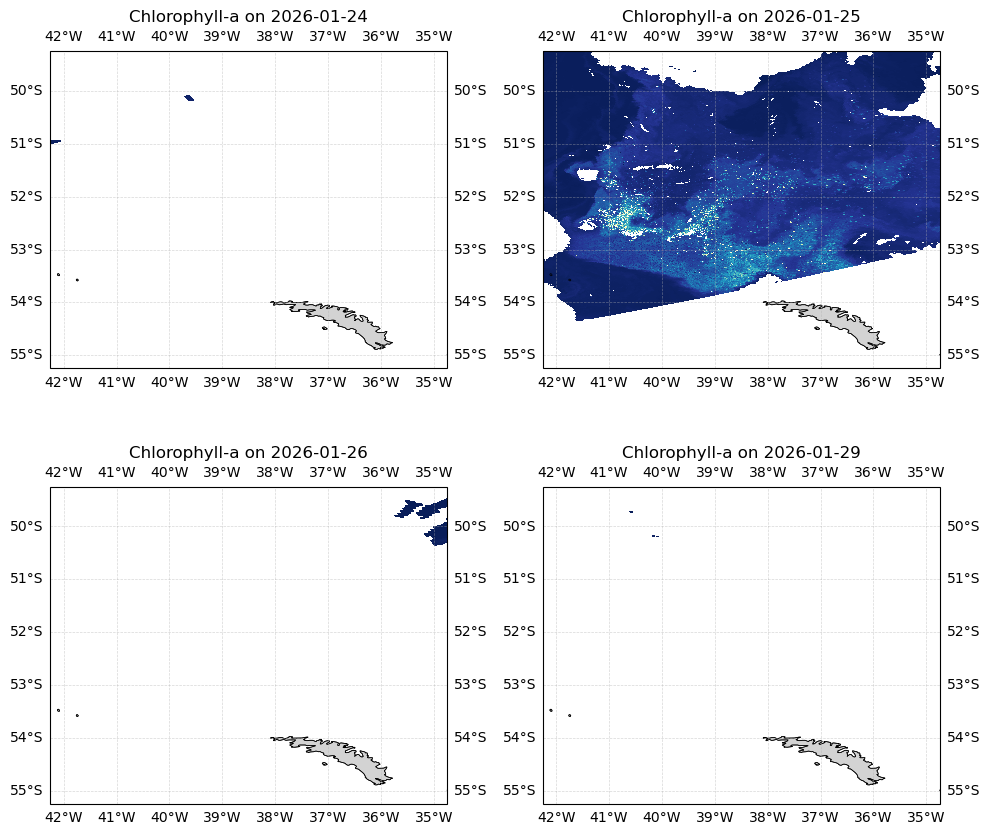

In [67]:
# in sequence, plotting out chlor_a data of each granule

# FIX: Can't use 'projection' argument in plt.subplots; must create subplot axes with projection manually.
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
for i in range(len(results_bgc)):
    # Replace normal axes with GeoAxes with Cartopy projection
    fig.delaxes(axes[i])
    ax = fig.add_subplot(2, 2, i + 1, projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    # Reload data
    dt_bgc = xr.open_datatree(granule_bgc[i])
    ds_bgc = xr.merge(dt_bgc.to_dict().values())
    chlor_a = ds_bgc['chlor_a'].values
    lat = ds_bgc['latitude'].values
    lon = ds_bgc['longitude'].values
    
    # Plot data
    mesh = ax.pcolormesh(lon, lat, chlor_a, transform=ccrs.PlateCarree(),
                         cmap="YlGnBu_r", vmin=0.01, vmax=10.0)
    date = datetime.strptime(str(granule_bgc[i])[109:117], '%Y%m%d')
    ax.set_title(f"Chlorophyll-a on {date.strftime('%Y-%m-%d')}")
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    # Optionally add colorbar per subplot (or globally afterwards)
    plt.tight_layout()
# Optionally add a single colorbar for all subplots:
# fig.colorbar(mesh, ax=fig.get_axes(), orientation='vertical', shrink=0.8)


QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

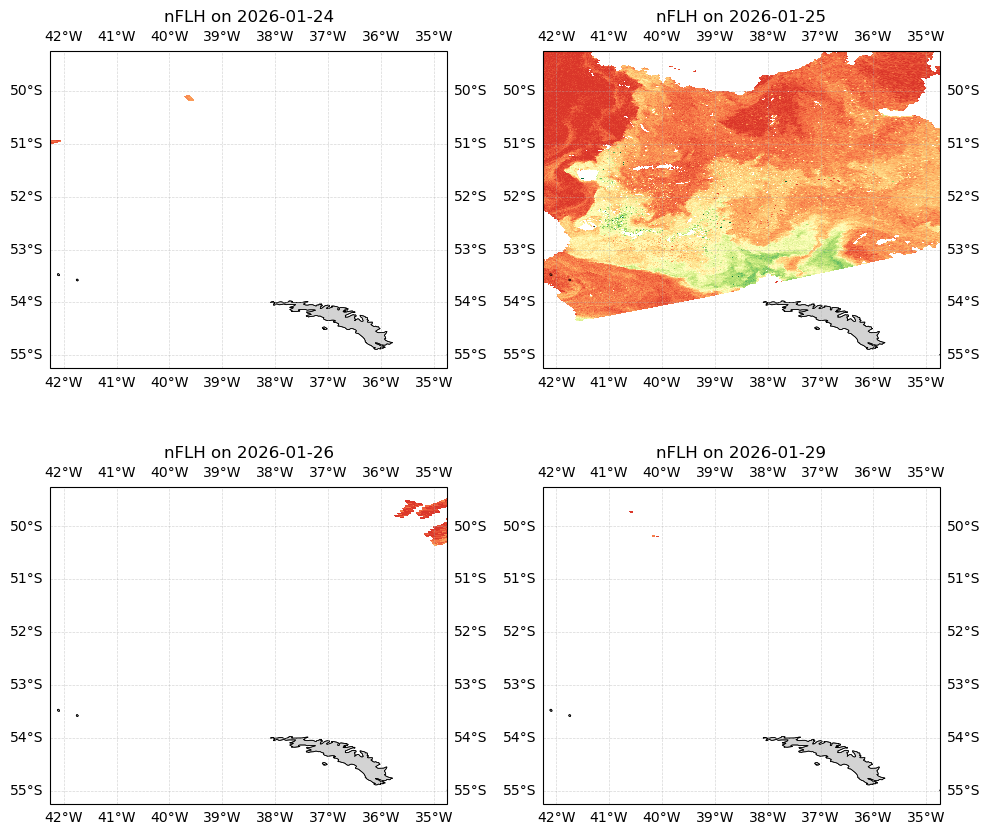

In [71]:
# do the same for nflh
granule_aop = earthaccess.open(results_aop)
# in sequence, plotting out nflh data of each granule

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
for i in range(len(granule_aop)):
    # Replace normal axes with GeoAxes with Cartopy projection
    fig.delaxes(axes[i])
    ax = fig.add_subplot(2, 2, i + 1, projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    # Reload data
    dt_bgc = xr.open_datatree(granule_aop[i])
    ds_bgc = xr.merge(dt_bgc.to_dict().values())
    if 'nflh' not in ds_bgc:
        # If nflh is missing, skip or warn
        ax.set_title("nFLH band not found")
        continue
    nflh = ds_bgc['nflh'].values
    lat = ds_bgc['latitude'].values
    lon = ds_bgc['longitude'].values

    # Plot data
    mesh = ax.pcolormesh(lon, lat, nflh, transform=ccrs.PlateCarree(),
                         cmap="RdYlGn", vmin=-0.1, vmax=0.8)
    date = datetime.strptime(str(granule_bgc[i])[109:117], '%Y%m%d')
    ax.set_title(f"nFLH on {date.strftime('%Y-%m-%d')}")
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    plt.tight_layout()
# Optionally add a single colorbar for all subplots:
# fig.colorbar(mesh, ax=fig.get_axes(), orientation='vertical', shrink=0.8)

#### <b>Single granule </b>

In [6]:
# obtain nflh & chlor_a for the second granule
granule_aop = earthaccess.open(results_aop)
dt_aop = xr.open_datatree(granule_aop[0])
ds_aop = xr.merge(dt_aop.to_dict().values())
granule_bgc = earthaccess.open(results_bgc)
dt_bgc = xr.open_datatree(granule_bgc[0])
ds_bgc = xr.merge(dt_bgc.to_dict().values())



QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

In [12]:
nflh = ds_aop['nflh'].values
chlor_a = ds_bgc['chlor_a'].values
poc = ds_bgc['poc'].values
carbon_phyto = ds_bgc['carbon_phyto'].values

lat = ds_bgc['latitude'].values
lon = ds_bgc['longitude'].values

In [31]:
import matplotlib.colors as mcolors   # add at top of cell or notebook


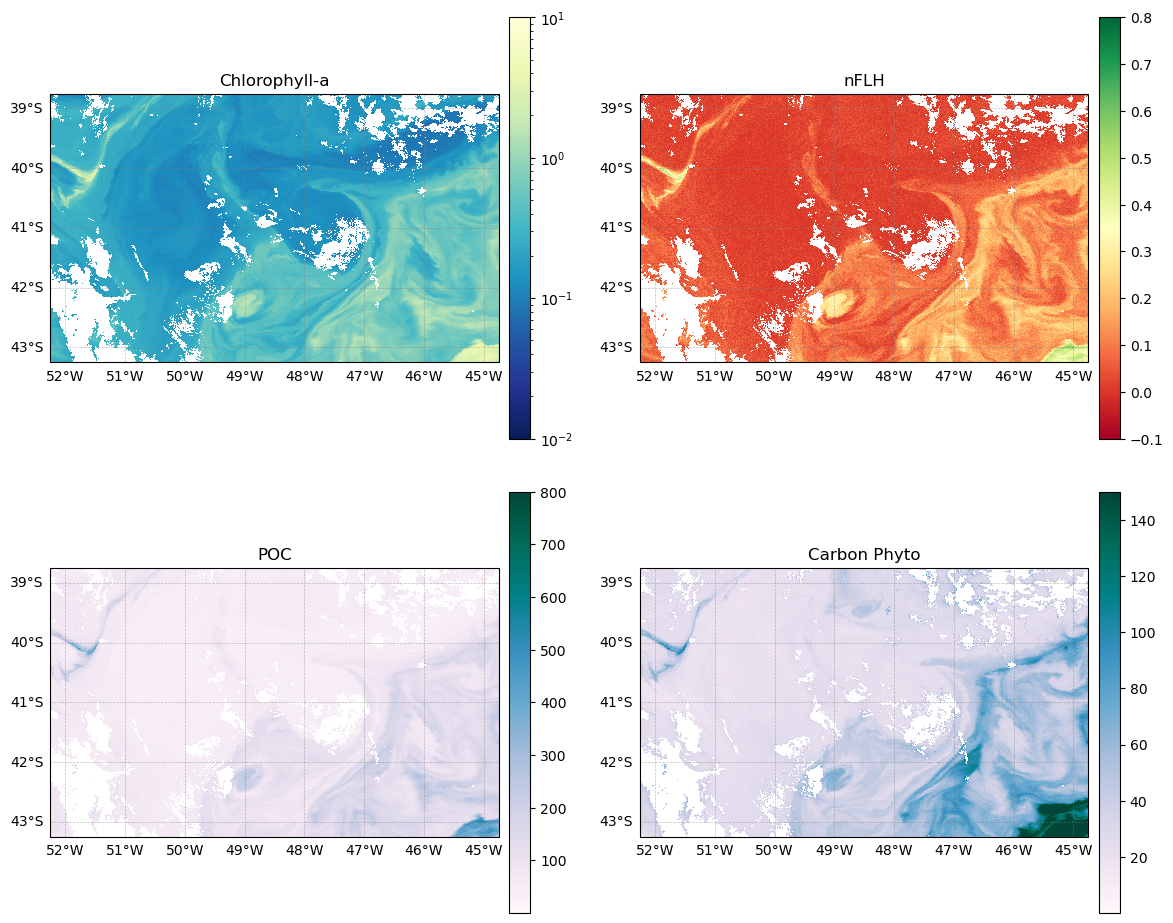

In [44]:
projection = ccrs.PlateCarree()

fig, axes = plt.subplots(
    2, 2, figsize=(12, 10),
    subplot_kw={"projection": projection},
)
axes = axes.flatten()

panels = [
        (chlor_a,      'Chlorophyll-a', 'YlGnBu_r', mcolors.LogNorm(vmin=0.01, vmax=10)),
        (nflh,         'nFLH',          'RdYlGn',   mcolors.Normalize(vmin=-0.1, vmax=0.8)),
        (poc,          'POC',           'PuBuGn',   mcolors.Normalize(vmin=0.01, vmax=800)),
        (carbon_phyto, 'Carbon Phyto', 'PuBuGn',   mcolors.Normalize(vmin=0.01, vmax=150)),
    ]

# set extent
set_extent = True
# buffer_bnd = .25
BBOX = [-52, -43, -45, -39]
lon_min = BBOX[0] - buffer_bnd
lon_max = BBOX[2] + buffer_bnd
lat_min = BBOX[1] - buffer_bnd
lat_max = BBOX[3] + buffer_bnd
extent = [lon_min, lon_max, lat_min, lat_max]

for ax, (data, title, cmap, norm) in zip(axes, panels):
    im = ax.pcolormesh(lon, lat, data,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap,
                       norm=norm)   
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_extent(extent, crs=ccrs.PlateCarree()) if set_extent else None
    ax.coastlines(resolution='10m', color='black', linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                      color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.85)

plt.tight_layout()

In [50]:
# more metrices:
# 1) fraction of carbon phyto to POC
carbon_phyto_poc = carbon_phyto / poc
# 2) ratio of chlor_a to POC
theta = chlor_a / poc
# 3) ratio of chlor_a to carbon phyto
phi = chlor_a / carbon_phyto
# 4) nflh to chlor_a
nflh_chlor_a = nflh / chlor_a
chlor_a_nflh = chlor_a / nflh

In [ ]:
np.nanquantile(carbon_phyto_poc, [0.01, 0.99]),\
np.nanquantile(theta, [0.01, 0.99]),\
np.nanquantile(phi, [0.01, 0.99]),\
np.nanquantile(nflh_chlor_a, [0.01, 0.99]),\
np.nanquantile(chlor_a_nflh, [0.01, 0.99])

(array([0.12579503, 1.01633095]),
 array([0.00186224, 0.00894663]),
 array([0.00226246, 0.05360913]),
 array([-3.62243977e-04,  6.25149975e-01]),
 array([-3303.73735352,    68.64797867]))

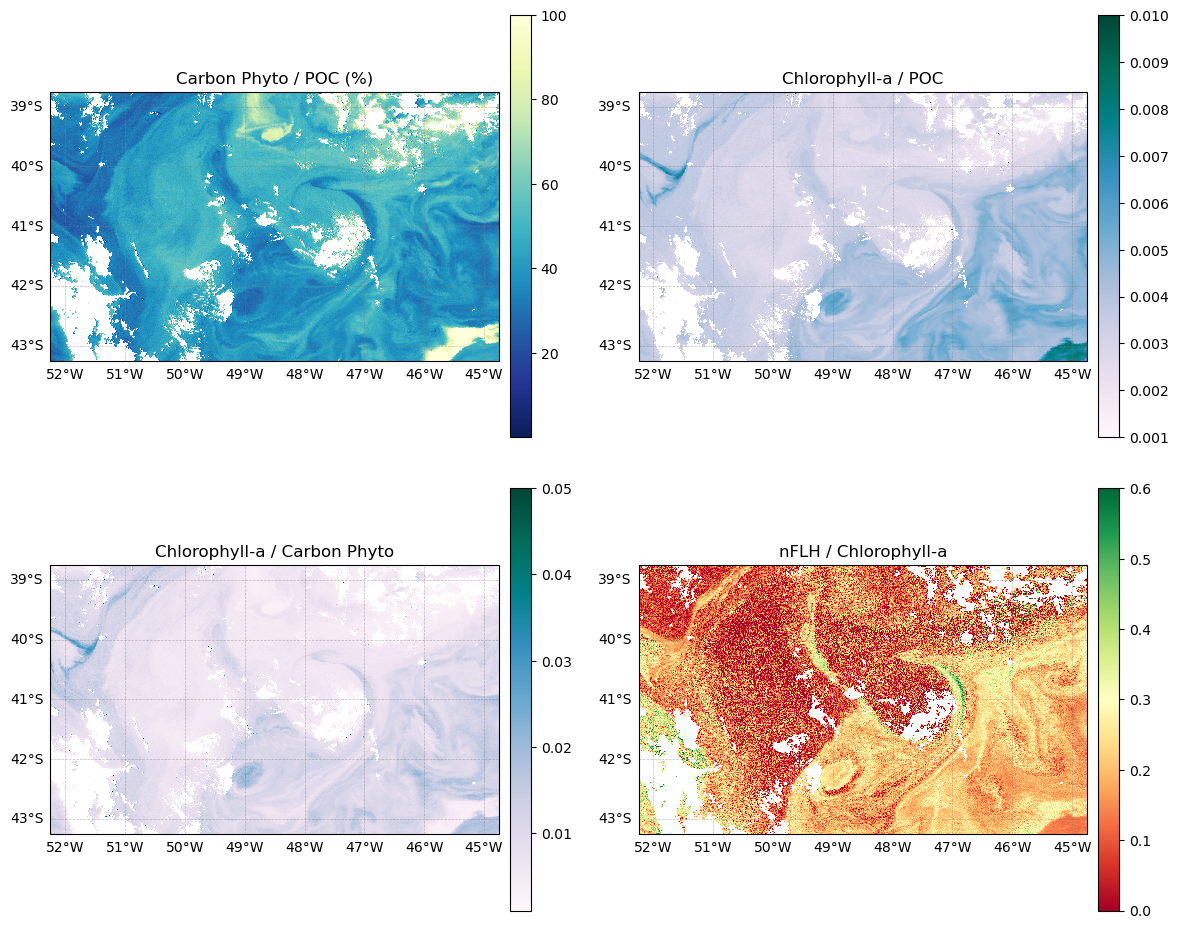

In [49]:
projection = ccrs.PlateCarree()

fig, axes = plt.subplots(
    2, 2, figsize=(12, 10),
    subplot_kw={"projection": projection},
)
axes = axes.flatten()

# set extent
buffer_bnd = .25
BBOX = [-52, -43, -45, -39]
lon_min = BBOX[0] - buffer_bnd
lon_max = BBOX[2] + buffer_bnd
lat_min = BBOX[1] - buffer_bnd
lat_max = BBOX[3] + buffer_bnd
extent = [lon_min, lon_max, lat_min, lat_max]

panels = [
    (carbon_phyto_poc * 100,  'Carbon Phyto / POC (%)',     'YlGnBu_r', 0.01, 100),
    (theta,             'Chlorophyll-a / POC',    'PuBuGn',   0.001, .01),
    (phi,               'Chlorophyll-a / Carbon Phyto', 'PuBuGn', 0.001, .05),
    (nflh_chlor_a,      'nFLH / Chlorophyll-a',   'RdYlGn', 0.0, .6),
]

for ax, (data, title, cmap, vmin, vmax) in zip(axes, panels):
    im = ax.pcolormesh(lon, lat, data,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_extent(extent, crs=ccrs.PlateCarree()) if set_extent else None
    ax.coastlines(resolution='10m', color='black', linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                      color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.85)

plt.tight_layout()

#### <b>nFLH</b>

In [90]:
nflh = ds_aop['nflh'].values
chlor_a = ds_bgc['chlor_a'].values
lat = ds_bgc['latitude'].values
lon = ds_bgc['longitude'].values

mask = (lat >= bbox[1]) & (lat <= bbox[3]) & (lon >= bbox[0]) & (lon <= bbox[2])
chlor_a_mask = np.where(mask, chlor_a, np.nan)
nflh_mask = np.where(mask, nflh, np.nan)

Text(0, 0.5, 'chlor_a')

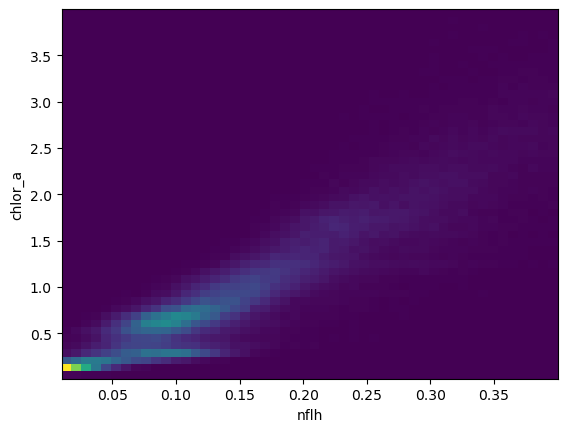

In [119]:
# flatten & remove nan
nflh_mask_flat = nflh_mask.flatten()
chlor_a_mask_flat = chlor_a_mask.flatten()
nanflag = np.isnan(nflh_mask_flat) | np.isnan(chlor_a_mask_flat)
nflh_mask_flat = nflh_mask_flat[~nanflag]
chlor_a_mask_flat = chlor_a_mask_flat[~nanflag]
# subset nflh_mask_flat & chlor_a_mask_flat to be within 0.1 to 1.0 and 0.1 to 10.0, respectively
threshold_flag = (nflh_mask_flat >= 0.01) & (nflh_mask_flat <= .4) & (chlor_a_mask_flat >= 0.01) & (chlor_a_mask_flat <= 4.0)
nflh_mask_flat = nflh_mask_flat[threshold_flag]
chlor_a_mask_flat = chlor_a_mask_flat[threshold_flag]
# 2d histogram
plt.hist2d(nflh_mask_flat, chlor_a_mask_flat, bins=50)
plt.xlabel('nflh')
plt.ylabel('chlor_a')



(0.0, 10.0)

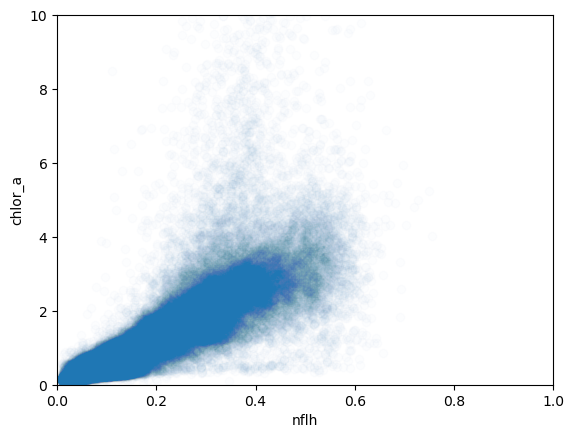

In [112]:
# scatter plot
plt.scatter(nflh_mask_flat, chlor_a_mask_flat, alpha=0.01)
plt.xlabel('nflh')
plt.ylabel('chlor_a')
plt.xlim(0, 1)
plt.ylim(0, 10)
